In [35]:
from src.neural.loader import DataLoader
from src.neural.preprocessing import DatasetProcessor
from src.models.model_training import ModelTrainer
import src.utils as utils
import os
import csv
import yaml
import torch
import torch.nn as nn
from torch.utils.data import DataLoader as TorchDataLoader, TensorDataset
import numpy as np
from sklearn.model_selection import train_test_split
from src.models.model_neural_predictor import FnirsFeaturePredictor
import copy

In [36]:
domain="flappy"

In [37]:
with open("configs/test.yaml") as f:
    base = yaml.safe_load(f)

with open(f"configs/domains/{domain}.yaml") as f:
        domain_base = yaml.safe_load(f)
        domain_cfg = copy.deepcopy(domain_base)

        cfg = copy.deepcopy(base)

        cfg["experiment"].update({
            "domain": domain_cfg["experiment"]["domain"],
            "task": "Pooled",
            "pretrained_success_rate": domain_cfg["experiment"]["pretrained_success_rate"],
        })

        cfg["mlp"].update({
            "binary_hidden_layer_sizes": domain_cfg["mlp"]["binary_hidden_layer_sizes"],
            "ternary_hidden_layer_sizes": domain_cfg["mlp"]["ternary_hidden_layer_sizes"],
            "regressor_hidden_layer_sizes": domain_cfg["mlp"]["regressor_hidden_layer_sizes"],
            "reg_activation": domain_cfg["mlp"]["reg_activation"],
            "early_stopping": domain_cfg["mlp"]["early_stopping"],
            "binary_alpha": domain_cfg["mlp"]["binary_alpha"],
            "ternary_alpha": domain_cfg["mlp"]["ternary_alpha"],
            "reg_alpha": domain_cfg["mlp"]["reg_alpha"],
            "binary_activation": domain_cfg["mlp"]["binary_activation"],
            "ternary_activation": domain_cfg["mlp"]["ternary_activation"],
            "reg_activation": domain_cfg["mlp"]["reg_activation"],
        })

        cfg["rl"].update({
            "n_episodes": domain_cfg["rl"]["n_episodes"],
            "algorithm": domain_cfg["rl"]["algorithm"],
            "steps": domain_cfg["rl"]["steps"],
            "action_space": domain_cfg["rl"]["action_space"],
            "observation_space": domain_cfg["rl"]["observation_space"],
            "buffer_type": cfg["rl"]["buffer_type"]

        })

In [51]:
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

def train_fnirs_predictor(
    states: np.ndarray,
    fnirs_targets: np.ndarray,
    state_dim: int,
    hidden_sizes=(256, 256),
    epochs: int = 80,
    lr: float = 1e-3,
    batch_size: int = 256,
    test_size: float = 0.1,
    random_state: int = 42,
    device = None,
    verbose: bool = False,
) -> FnirsFeaturePredictor:
    """
    Trains FnirsFeaturePredictor and plots learning curves (MSE and R2) as for a publication.

    Returns:
        model: Trained FnirsFeaturePredictor.
    """
    S = np.asarray(states, dtype=np.float32)
    Y = np.asarray(fnirs_targets, dtype=np.float32)
    if S.shape[0] != Y.shape[0]:
        raise ValueError(
            f"states and fnirs_targets must have the same length; got {S.shape[0]} vs {Y.shape[0]}"
        )
    if S.shape[1] != state_dim:
        raise ValueError(f"states second dim {S.shape[1]} != state_dim {state_dim}")

    mask = np.isfinite(S).all(axis=1) & np.isfinite(Y).all(axis=1)
    S, Y = S[mask], Y[mask]

    if len(S) < 10:
        raise ValueError(f"Too few rows for fNIRS predictor training: {len(S)}")

    S_tr, S_va, Y_tr, Y_va = train_test_split(
        S, Y, test_size=test_size, random_state=random_state
    )

    fnirs_dim = Y.shape[1]
    model = FnirsFeaturePredictor(
        state_dim=state_dim,
        fnirs_dim=fnirs_dim,
        hidden_sizes=hidden_sizes,
    )
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()

    tr_ds = TensorDataset(
        torch.from_numpy(S_tr).float(), torch.from_numpy(Y_tr).float()
    )
    tr_loader = TorchDataLoader(tr_ds, batch_size=batch_size, shuffle=True)
    S_va_t = torch.from_numpy(S_va).float()
    Y_va_t = torch.from_numpy(Y_va).float()

    train_losses = []
    val_losses = []
    train_r2s = []
    val_r2s = []

    for ep in range(epochs):
        model.train()
        epoch_loss = 0
        y_true_ep = []
        y_pred_ep = []
        count = 0
        for xb, yb in tr_loader:
            xb = xb
            yb = yb
            opt.zero_grad()
            pred = model(xb)
            loss = loss_fn(pred, yb)
            loss.backward()
            opt.step()
            epoch_loss += loss.item() * xb.size(0)
            count += xb.size(0)
            y_true_ep.append(yb.detach().cpu().numpy())
            y_pred_ep.append(pred.detach().cpu().numpy())
        train_loss = epoch_loss / count
        train_losses.append(train_loss)
        # Flatten batch lists to arrays for R2 calculation
        y_true_train = np.concatenate(y_true_ep, axis=0)
        y_pred_train = np.concatenate(y_pred_ep, axis=0)
        train_r2 = r2_score(y_true_train, y_pred_train, multioutput='uniform_average')
        train_r2s.append(train_r2)

        model.eval()
        with torch.no_grad():
            va_pred = model(S_va_t)
            va_loss = loss_fn(va_pred, Y_va_t).item()
            y_true_val = Y_va_t.detach().cpu().numpy()
            y_pred_val = va_pred.detach().cpu().numpy()
            val_r2 = r2_score(y_true_val, y_pred_val, multioutput='uniform_average')
        val_losses.append(va_loss)
        val_r2s.append(val_r2)

        if verbose and (ep == 0 or ep == epochs - 1 or (ep + 1) % 20 == 0):
            print(
                f"fNIRS predictor epoch {ep + 1}/{epochs} — "
                f"train MSE: {train_loss:.6f}, val MSE: {va_loss:.6f}, "
                f"train R2: {train_r2:.4f}, val R2: {val_r2:.4f}"
            )

    # Plot training and validation loss
    fig, ax1 = plt.subplots(figsize=(7, 5))

    ax1.plot(range(1, epochs + 1), train_losses, label="Train MSE", color='C0', lw=2)
    ax1.plot(range(1, epochs + 1), val_losses, label="Validation MSE", color='C1', lw=2)
    ax1.set_xlabel("Epoch", fontsize=13)
    ax1.set_ylabel("Mean Squared Error", fontsize=13, color='black')
    ax1.tick_params(axis='y', labelcolor='black')
    ax1.legend(loc="upper right", fontsize=11)
    ax1.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)

    ax2 = ax1.twinx()
    ax2.plot(range(1, epochs + 1), train_r2s, label="Train $R^2$", color='C2', lw=2, linestyle='--')
    ax2.plot(range(1, epochs + 1), val_r2s, label="Validation $R^2$", color='C3', lw=2, linestyle='--')
    ax2.set_ylabel("$R^2$ Score", fontsize=13, color='black')
    ax2.tick_params(axis='y', labelcolor='black')
    ax2.legend(loc="lower right", fontsize=11)

    plt.title("fNIRS Predictor Learning Curves", fontsize=14, pad=8)
    fig.tight_layout()
    plt.show()

    print(f"Final training MSE: {train_losses[-1]:.6f} | Final validation MSE: {val_losses[-1]:.6f}")
    print(f"Final training R2:  {train_r2s[-1]:.4f} | Final validation R2:  {val_r2s[-1]:.4f}")

    return model

In [56]:
def run(cfg, run_name = "test", verbose = False, DATA_PATH = '.', RESULTS_PATH='.', RESULTS_FILE_NAME = 'trial_results.csv', inverse = False):

    # env = utils.load_domain(cfg["experiment"]["domain"], cfg["rl"]["steps"])
    # agent = utils.load_agent(cfg["rl"]["algorithm"], cfg["rl"]["buffer_type"], space = (cfg["rl"]["observation_space"], cfg["rl"]["action_space"]), pretrained_success_rate = cfg["experiment"]["pretrained_success_rate"], verbose = verbose)
    
    # if cfg["experiment"]["integration_type"] == "early":
    #     print("Early Integration")
    #     from src.training_loop_early import train, train_robot

    # if cfg["experiment"]["integration_type"] == "interleaved":
    #     from src.training_loop import train, train_robot

    if not os.path.exists(os.path.join(DATA_PATH, 'fNIRS/LabeledData/')):
        try:
            DATA_PATH = os.path.join(os.environ.get("HOME", ""),
                        '/Users/juliasantaniello/Desktop/fNIRS-2-RL/Experiment/ParticipantData/')
            assert os.path.exists(os.path.join(DATA_PATH, 'fNIRS/LabeledData/'))
        except AssertionError:
            print("Please store path to participant date in DATA_PATH")

    labeled_data_source_folder = os.path.join(DATA_PATH, 'fNIRS/LabeledData/')
    rl_taskstats_source_folder = os.path.join(DATA_PATH, 'TaskData/')
    filtered_data_source_folder = os.path.join(DATA_PATH, 'fNIRS/FilteredData/')

    # get conditions
    condition_list = utils.get_conditions(cfg["experiment"]["domain"], cfg["experiment"]["task"], verbose = verbose)
    
    # load neural and rl data
    loader = DataLoader(
        fnirs_data_source_path=filtered_data_source_folder,
        task_data_source_path=rl_taskstats_source_folder,
        labeled_data_source_path=labeled_data_source_folder,
        participant_list = cfg["experiment"]["participant_list"],
        conditions_list = condition_list,
    )

    fnirs_df = loader.load_fnirs()     
    task_df  = loader.load_task()
    labels_df = loader.load_labels()

    # align timestamps
    processor = DatasetProcessor(verbose = verbose)
    aligned_df, fnirs_channels = processor.align_streams(
        fnirs_df,
        task_df,
        labels_df,
        resample_rate_hz = cfg["neural"]["fnirs_rate_hz"],
    )

    shifted_df = processor.shift_labels_for_delay(aligned_df, delay_s = cfg["neural"]["temporal_shift"], verbose = verbose)

    X, y, selected_indices = processor.build_balanced_dataset(
        shifted_df,
        fnirs_channels = fnirs_channels,
        label_col = "label_shifted",
        granularity = cfg["experiment"]["model_granularity"],
        window_duration_s = cfg["neural"]["window_size_s"],
        resample_rate_hz = cfg["neural"]["fnirs_rate_hz"],
        random_state = cfg["experiment"]["random_state"],
        return_indices = True
    )

    modelTrainer = ModelTrainer(cfg = cfg["mlp"], seed = cfg["experiment"]["random_state"], verbose = verbose)
    classifier, report = modelTrainer.train_classifier(X, y, granularity = cfg["experiment"]["model_granularity"], random_state =  cfg["experiment"]["random_state"])
    
    print("MLP Report: \n", report)


    state_dim = int(cfg["rl"]["observation_space"])

    S_list, Fn_list = processor.build_supervised_dataset_fnirs(
        shifted_df,
        fnirs_channels=fnirs_channels,
        window_duration_s=cfg["neural"]["window_size_s"],
        resample_rate_hz=cfg["neural"]["fnirs_rate_hz"],

    )

    S_list = S_list[selected_indices]
    Fn_list = Fn_list[selected_indices]

    return S_list, Fn_list, state_dim, X, y, classifier

    # if cfg["experiment"]["domain"][0].lower() == "l" or cfg["experiment"]["domain"][0].lower() == "f":        
    #     results_dictionary = train(env=env, 
    #         processor = processor,
    #         task_df = task_df, 
    #         agent = agent, 
    #         flags = cfg["experiment"]["experiment_list"], 
    #         granularity = cfg["experiment"]["model_granularity"],
    #         episodes_num = cfg["rl"]["n_episodes"],
    #         clf = classifier, 
    #         ml = modelTrainer, 
    #         fnirs_channel_names=fnirs_channels, 
    #         smoothing_window_size =  cfg["neural"]["smoothing_window_size"], 
    #         window_duration_s = cfg["neural"]["window_size_s"], 
    #         shift = cfg["neural"]["temporal_shift"], 
    #         fnirs_rate_hz = cfg["neural"]["fnirs_rate_hz"],
    #         beta = cfg["neural"]["beta"],
    #         noise = cfg["mlp"]["model_noise"],
    #         seed = cfg["experiment"]["random_state"],
    #         buffer_type = cfg["rl"]["buffer_type"],
    #         steps = cfg["rl"]["steps"], 
    #         save_results = True,
    #         save_to_csv = False,
    #         verbose = verbose)
    # else:
    #     results_dictionary = train_robot(
    #         env=env,
    #         processor=processor,
    #         task_df=task_df,
    #         agent=agent,
    #         experiment_list=cfg["experiment"]["experiment_list"],
    #         granularity=cfg["experiment"]["model_granularity"],
    #         episodes_num=cfg["rl"]["n_episodes"],
    #         clf=classifier,
    #         ml=modelTrainer,
    #         fnirs_channel_names=fnirs_channels,
    #         smoothing_window_size=cfg["neural"]["smoothing_window_size"],
    #         window_duration_s=cfg["neural"]["window_size_s"],
    #         shift=cfg["neural"]["temporal_shift"],
    #         fnirs_rate_hz=cfg["neural"]["fnirs_rate_hz"],
    #         beta=cfg["neural"]["beta"],
    #         noise=cfg["mlp"]["model_noise"],
    #         seed = cfg["experiment"]["random_state"],
    #         buffer_type=cfg["rl"]["buffer_type"],
    #         steps=cfg["rl"]["steps"],
    #         save_results=True,
    #         save_to_csv=False,
    #         verbose=verbose
    #     )

    # trial_dict = {}
    # trial_dict = {"parameters": cfg, "results": results_dictionary}

    # def flatten_dict(d, parent_key='', sep='_'):
    #     items = []
    #     for k, v in d.items():
    #         new_key = f"{parent_key}{sep}{k}" if parent_key else k
    #         if isinstance(v, dict):
    #             items.extend(flatten_dict(v, new_key, sep=sep).items())
    #         else:
    #             items.append((new_key, v))
    #     return dict(items)

    # flat_trial = flatten_dict(trial_dict)

    # csv_path = os.path.join(RESULTS_PATH,'src/results/', RESULTS_FILE_NAME)
    # write_header = not os.path.exists(os.path.join(RESULTS_PATH,'src/results/', RESULTS_FILE_NAME))
    # with open(csv_path, 'a', newline='') as f:
    #     writer = csv.DictWriter(f, fieldnames=flat_trial.keys())
    #     if write_header:
    #         writer.writeheader()
    #     writer.writerow(flat_trial)

In [57]:
S_list, Fn_list, state_dim, X, y, classifier = run(cfg, verbose=False)


MLP Report: 
               precision    recall  f1-score   support

         0.0       0.70      0.84      0.76      1130
         1.0       0.80      0.63      0.71      1129

    accuracy                           0.74      2259
   macro avg       0.75      0.74      0.73      2259
weighted avg       0.75      0.74      0.73      2259



IndexError: index 27491 is out of bounds for axis 0 with size 27456

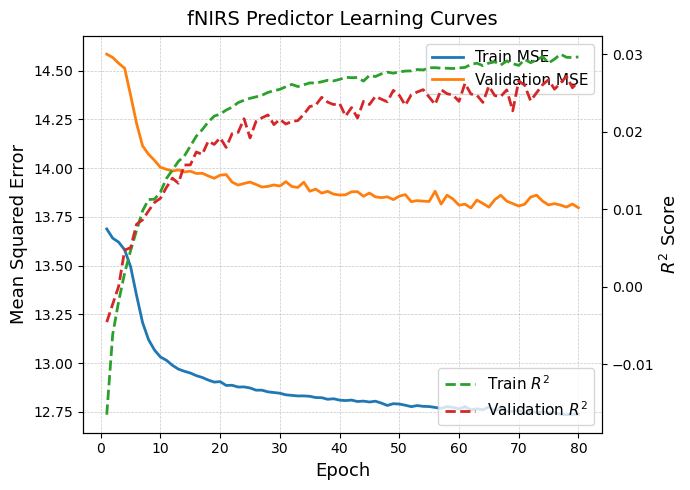

Final training MSE: 12.738889 | Final validation MSE: 13.796668
Final training R2:  0.0296 | Final validation R2:  0.0264


In [ ]:
fnirs_predictor = train_fnirs_predictor(
        S_list,
        Fn_list,
        state_dim=state_dim
    )

In [ ]:
print(X[0][0:3])
print(Fn_list[0][0:3])

[-1.29252798e-01  7.87831415e-02 -2.70520880e-01 -2.13487606e-02
 -4.12009922e-01  3.21466180e-03  6.22950751e-01  2.70874696e-01
  8.16313521e-03  8.21270652e-03  1.84666189e-02  9.67240504e-03
  6.58872533e-03  6.10176650e-03  4.45557058e-02  6.70894064e-03
  5.16392799e-03  5.17748359e-03 -1.29069656e-02 -6.02639543e-03
  3.74842108e-03  3.88986026e-03 -2.70369210e-02 -3.95399991e-03
 -1.39580654e-01  6.84281743e-02 -2.44706949e-01 -9.29596978e-03
 -4.19506764e-01 -4.56505872e-03  6.77024594e-01  2.78782696e-01
 -1.69571968e+00 -1.71678219e+00 -3.96528197e-01  1.78406671e+00
 -2.11294560e+00 -1.64575793e+00  1.91080774e+00  2.01852904e+00
  3.14762898e+00  3.21663786e+00 -1.57796100e+00  3.43891091e+00
  4.56352802e+00  2.98504091e+00  3.86495831e+00  4.23438608e+00]
[-1.95013606e-02 -2.83472481e-01 -3.84852841e+00 -1.85146343e-01
  6.03977169e+00  2.87316161e+00 -4.86529012e+01 -7.19904776e+00
  4.82674842e-02  5.53834886e-03  2.00984094e-01  3.67815955e-02
  1.57563893e-01  1.7867